# Chapter 05: Algorithm Evaluation and Error Analysis

Source orientation: printed pages 132-150; PDF pages 150-168.

This notebook is an original, standalone computational treatment of Chapter 05. The source pages were used to identify the chapter's structure and terminology: performance bounds for estimators, residual and estimation error, tangent-plane reasoning, covariance propagation, homography transfer uncertainty, and Monte Carlo covariance. The prose, code, diagrams, and generated artifacts here are authored for this course and do not copy textbook prose, figures, screenshots, page crops, long exercise text, or page layouts.

## Chapter Goal

Build a practical evaluation workflow for projective estimators: predict the lower-bound behavior of residuals, propagate covariance through a homography, inspect point-transfer error ellipses, and use Monte Carlo trials to expose bias, variance, degeneracy, and reprojection diagnostics.


## Computational Translation Guide

- A measurement vector $X$ is a stacked list of image coordinates. In a homography experiment with noise in the second image only, $X$ contains the $2n$ coordinates of the transferred points.
- A model manifold is the set of all measurement vectors that can be produced by some parameter vector $P$. For a planar projectivity, $P$ is the homography, modulo scale.
- Residual error compares the noisy measurement with the estimated measurement. Estimation error compares the estimated measurement with the noise-free truth. They answer different questions.
- The tangent-plane approximation turns maximum-likelihood estimation into orthogonal projection in measurement space. That is the geometric reason the residual and estimation components split by Pythagoras.
- Covariance propagation is a Jacobian computation. Forward propagation uses $J \Sigma J^T$; backward propagation for estimated parameters uses a pseudo-inverse of $J^T \Sigma^{-1} J$ because homogeneous parameters have a scale null direction.
- Monte Carlo simulation is the audit trail. It checks whether the theoretical small-noise predictions survive the actual estimator, noise level, and point configuration.


## Library Routing

| Chapter concept | Representation | Library route | Why this route | Artifact/check |
| --- | --- | --- | --- | --- |
| Error bounds for residual and estimation error | Curves over the number of correspondences | NumPy plus Matplotlib | The formulas are low-dimensional and need durable, labelled static comparison | `homography-error-bound-curves.png`; monotone and endpoint assertions |
| Tangent-plane convergence identity | Orthogonal projection diagram | Matplotlib | The proof move is geometric: a measurement decomposes into tangent and normal components | `tangent-plane-convergence-identity.png`; squared-distance equality |
| Covariance propagation through homography transfer | Jacobian-derived error ellipses and radial RMS curve | NumPy, SciPy chi-square, Matplotlib | The geometry is local covariance in the image plane; ellipses expose anisotropy and extrapolation | `point-transfer-covariance-ellipses.png`; PSD and radial formula checks |
| Noise sweeps | Empirical vs theoretical residual/estimation curves | pandas, Plotly, Matplotlib | Plotly gives an inspectable HTML diagnostic; Matplotlib gives a durable static artifact | `homography-noise-sweep-reprojection-diagnostics.html/.png`; ratio checks |
| Monte Carlo estimator spread | Probe-point clouds, covariance ellipses, bias/variance table | NumPy, OpenCV, pandas, Matplotlib | OpenCV anchors the experiment in a standard CV homography API; the custom DLT keeps the math visible | `monte-carlo-configuration-spread.png`; covariance and degeneracy-spread checks |


## Visual Storyboard

1. Draw the theoretical residual and estimation bounds for one-image and two-image noise. Learner inspection target: residual can rise while estimation error falls because they live in complementary subspaces.
2. Draw the tangent-plane projection proof scaffold. Learner inspection target: the measured-to-true vector splits into estimated-to-true and measured-to-estimated components.
3. Compute homography-parameter covariance from transfer Jacobians and display point-transfer ellipses. Learner inspection target: uncertainty grows outside the support of the correspondences and becomes anisotropic.
4. Sweep image noise and compare empirical DLT diagnostics with the small-noise bound. Learner inspection target: empirical residuals should track the bound when the linear approximation is valid.
5. Run Monte Carlo trials for well-spread and nearly collinear point layouts. Learner inspection target: similar reprojection residuals can hide radically different transfer uncertainty.


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-05"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

import math

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import chi2

from utils.artifacts import (
    assert_artifacts,
    display_artifact,
    relative_to_book,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

plt.rcParams.update({
    "figure.figsize": (8.0, 5.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

rng = np.random.default_rng(505)
artifact_paths: list[Path] = []
table_paths: list[Path] = []
check_paths: list[Path] = []


In [2]:
def homogenize(points: np.ndarray) -> np.ndarray:
    pts = np.asarray(points, dtype=float)
    return np.concatenate([pts, np.ones((*pts.shape[:-1], 1), dtype=float)], axis=-1)


def dehomogenize(points: np.ndarray, *, eps: float = 1e-12) -> np.ndarray:
    pts = np.asarray(points, dtype=float)
    w = pts[..., -1:]
    safe = np.where(np.abs(w) < eps, np.sign(w) * eps + (w == 0) * eps, w)
    return pts[..., :-1] / safe


def apply_homography(H: np.ndarray, points: np.ndarray) -> np.ndarray:
    hp = homogenize(points) if np.asarray(points).shape[-1] == 2 else np.asarray(points, dtype=float)
    return dehomogenize((np.asarray(H, dtype=float) @ hp.T).T)


def normalize_points_2d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    pts = np.asarray(points, dtype=float)
    centroid = pts.mean(axis=0)
    centered = pts - centroid
    mean_dist = np.sqrt(np.sum(centered**2, axis=1)).mean()
    scale = math.sqrt(2.0) / mean_dist if mean_dist > 1e-12 else 1.0
    T = np.array([[scale, 0.0, -scale * centroid[0]], [0.0, scale, -scale * centroid[1]], [0.0, 0.0, 1.0]])
    return (T @ homogenize(pts).T).T, T


def dlt_homography(src: np.ndarray, dst: np.ndarray, *, normalized: bool = True) -> tuple[np.ndarray, np.ndarray]:
    if normalized:
        src_h, Ts = normalize_points_2d(src)
        dst_h, Td = normalize_points_2d(dst)
    else:
        src_h = homogenize(np.asarray(src, dtype=float))
        dst_h = homogenize(np.asarray(dst, dtype=float))
        Ts = np.eye(3)
        Td = np.eye(3)

    rows = []
    for x, xp in zip(src_h, dst_h):
        X, Y, W = x
        u, v, w = xp
        rows.append([0.0, 0.0, 0.0, -w * X, -w * Y, -w * W, v * X, v * Y, v * W])
        rows.append([w * X, w * Y, w * W, 0.0, 0.0, 0.0, -u * X, -u * Y, -u * W])
    _, singular_values, vt = np.linalg.svd(np.asarray(rows), full_matrices=False)
    Hn = vt[-1].reshape(3, 3)
    H = np.linalg.inv(Td) @ Hn @ Ts
    if abs(H[-1, -1]) > 1e-12:
        H = H / H[-1, -1]
    else:
        H = H / np.linalg.norm(H)
    return H, singular_values


def opencv_homography(src: np.ndarray, dst: np.ndarray) -> np.ndarray:
    H, _ = cv2.findHomography(np.asarray(src, dtype=np.float64), np.asarray(dst, dtype=np.float64), method=0)
    if H is None:
        raise RuntimeError("OpenCV could not estimate a homography")
    return H / H[-1, -1]


def homography_transfer_jacobian(H: np.ndarray, point: np.ndarray) -> np.ndarray:
    X = np.array([point[0], point[1], 1.0], dtype=float)
    mapped = H @ X
    u = mapped[0] / mapped[2]
    v = mapped[1] / mapped[2]
    w = mapped[2]
    return np.array([
        [X[0] / w, X[1] / w, X[2] / w, 0.0, 0.0, 0.0, -u * X[0] / w, -u * X[1] / w, -u * X[2] / w],
        [0.0, 0.0, 0.0, X[0] / w, X[1] / w, X[2] / w, -v * X[0] / w, -v * X[1] / w, -v * X[2] / w],
    ])


def transfer_jacobian_wrt_point(H: np.ndarray, point: np.ndarray) -> np.ndarray:
    X = np.array([point[0], point[1], 1.0], dtype=float)
    y = H @ X
    w = y[2]
    return np.array([
        [(H[0, 0] * w - y[0] * H[2, 0]) / w**2, (H[0, 1] * w - y[0] * H[2, 1]) / w**2],
        [(H[1, 0] * w - y[1] * H[2, 0]) / w**2, (H[1, 1] * w - y[1] * H[2, 1]) / w**2],
    ])


def rms_per_coordinate(a: np.ndarray, b: np.ndarray) -> float:
    diff = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    return float(np.sqrt(np.sum(diff**2) / diff.size))


def covariance_ellipse(cov: np.ndarray, level: float = 0.90) -> tuple[float, float, float]:
    vals, vecs = np.linalg.eigh((cov + cov.T) / 2.0)
    vals = np.clip(vals, 0.0, None)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    radius = math.sqrt(float(chi2.ppf(level, df=2)))
    width, height = 2.0 * radius * np.sqrt(vals)
    angle = math.degrees(math.atan2(vecs[1, 0], vecs[0, 0]))
    return float(width), float(height), float(angle)


def add_covariance_ellipse(ax, mean: np.ndarray, cov: np.ndarray, *, color: str, level: float = 0.90, visual_scale: float = 1.0, alpha: float = 0.22):
    width, height, angle = covariance_ellipse(cov, level=level)
    patch = Ellipse(
        xy=mean,
        width=visual_scale * width,
        height=visual_scale * height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        lw=1.2,
        alpha=alpha,
    )
    ax.add_patch(patch)
    return patch


## Performance Bounds: Residual Error Is Not Estimation Error

The chapter's first warning is subtle: an estimator can fit noisy measurements well while still being far from the noise-free truth. With exactly four point correspondences, a homography can interpolate the noisy points, so the residual can be zero even though the transfer is noisy. With more points, the model has to compromise. The residual grows toward a bound, while the estimation error can shrink because the extra correspondences constrain the true transformation.

The curves below use the tangent-plane calculation for a homography. The one-image case has $N=2n$ measurements and $d=8$ essential parameters. The two-image case has $N=4n$ measurements and $d=2n+8$ because the point positions are also estimated.


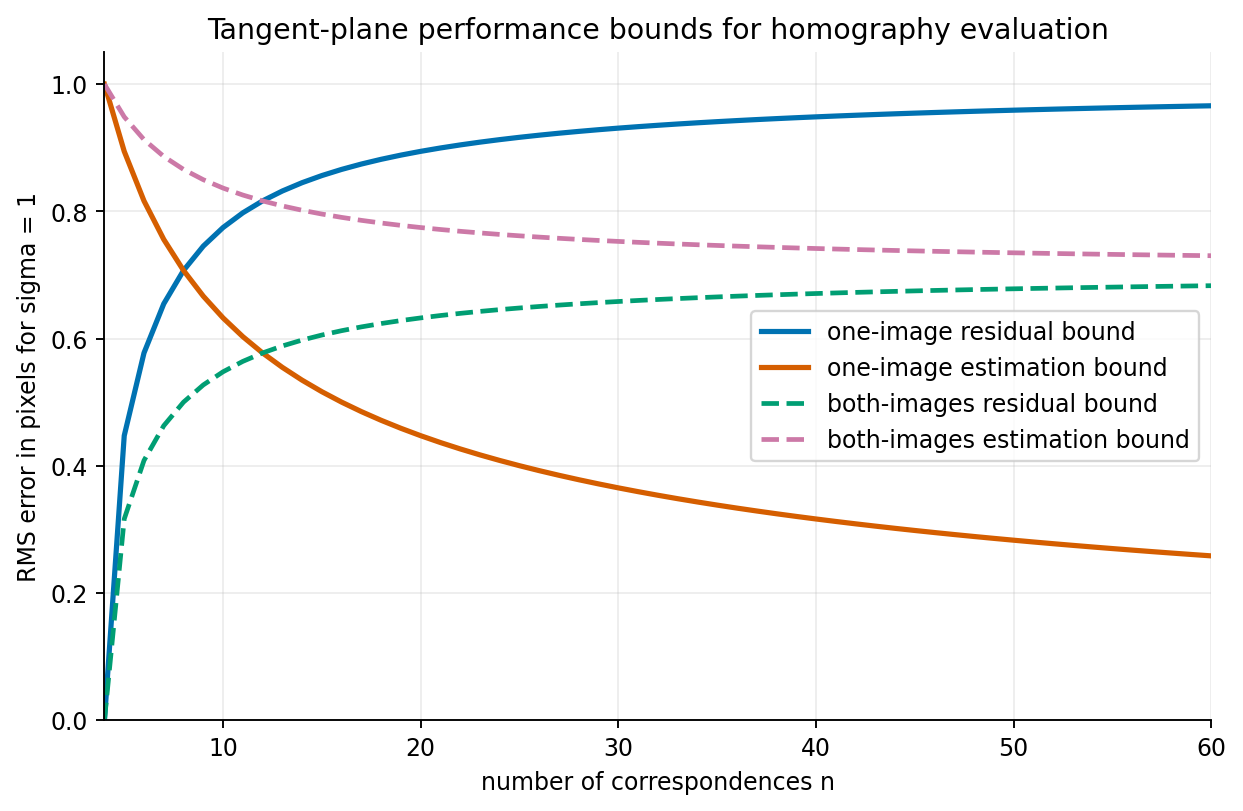

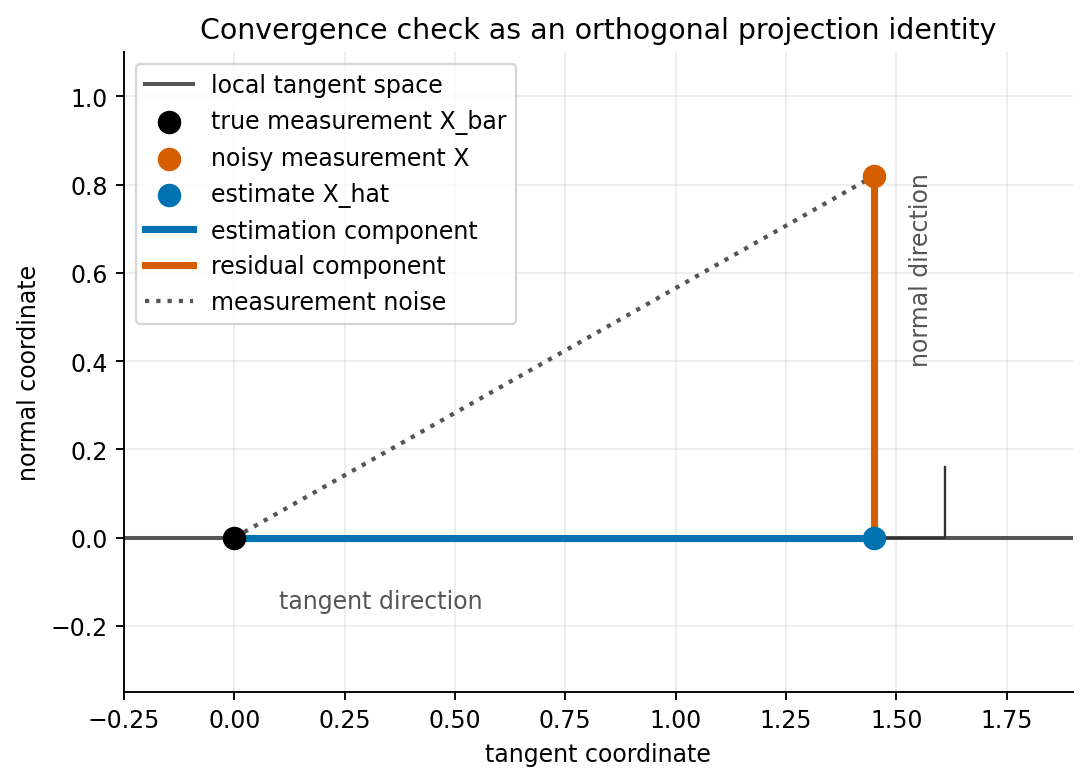

`artifacts/chapter-05/checks/performance-bound-and-tangent-plane-checks.json`

{'sigma_pixels': 1.0,
 'one_image_residual_at_four_points': 0.0,
 'one_image_estimation_at_four_points': 1.0,
 'one_image_estimation_at_sixty_points': 0.2581988897471611,
 'both_images_estimation_asymptote_reference': 0.7071067811865475,
 'pythagorean_left': 2.7748999999999997,
 'pythagorean_right': 2.7748999999999997,
 'pythagorean_gap': 0.0}

In [3]:
sigma = 1.0
n_values = np.arange(4, 61)

one_residual_bound = sigma * np.sqrt(np.maximum(0.0, 1.0 - 4.0 / n_values))
one_estimation_bound = sigma * np.sqrt(4.0 / n_values)
both_residual_bound = sigma * np.sqrt(np.maximum(0.0, (n_values - 4.0) / (2.0 * n_values)))
both_estimation_bound = sigma * np.sqrt((n_values + 4.0) / (2.0 * n_values))

fig, ax = plt.subplots(figsize=(8.4, 5.1))
ax.plot(n_values, one_residual_bound, color="#0072B2", lw=2.2, label="one-image residual bound")
ax.plot(n_values, one_estimation_bound, color="#D55E00", lw=2.2, label="one-image estimation bound")
ax.plot(n_values, both_residual_bound, color="#009E73", lw=2.0, ls="--", label="both-images residual bound")
ax.plot(n_values, both_estimation_bound, color="#CC79A7", lw=2.0, ls="--", label="both-images estimation bound")
ax.set_xlabel("number of correspondences n")
ax.set_ylabel("RMS error in pixels for sigma = 1")
ax.set_title("Tangent-plane performance bounds for homography evaluation")
ax.set_xlim(4, 60)
ax.set_ylim(0, 1.05)
ax.legend(loc="center right", frameon=True)

bound_path = save_matplotlib(fig, TOPIC, "figures", "homography-error-bound-curves.png", dpi=170)
plt.close(fig)
artifact_paths.append(bound_path)
display_artifact(bound_path, width=850)

X_true = np.array([0.0, 0.0])
X_measured = np.array([1.45, 0.82])
X_estimated = np.array([X_measured[0], 0.0])
left = float(np.sum((X_measured - X_true) ** 2))
right = float(np.sum((X_measured - X_estimated) ** 2) + np.sum((X_estimated - X_true) ** 2))
pythagorean_gap = abs(left - right)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.axhline(0, color="#555555", lw=1.7, label="local tangent space")
ax.scatter(*X_true, s=80, color="#000000", zorder=4, label="true measurement X_bar")
ax.scatter(*X_measured, s=80, color="#D55E00", zorder=4, label="noisy measurement X")
ax.scatter(*X_estimated, s=80, color="#0072B2", zorder=4, label="estimate X_hat")
ax.plot([X_true[0], X_estimated[0]], [X_true[1], X_estimated[1]], color="#0072B2", lw=3, label="estimation component")
ax.plot([X_estimated[0], X_measured[0]], [X_estimated[1], X_measured[1]], color="#D55E00", lw=3, label="residual component")
ax.plot([X_true[0], X_measured[0]], [X_true[1], X_measured[1]], color="#555555", lw=1.8, ls=":", label="measurement noise")
ax.plot([X_estimated[0], X_estimated[0] + 0.16, X_estimated[0] + 0.16], [0.0, 0.0, 0.16], color="#333333", lw=1.0)
ax.text(0.1, -0.16, "tangent direction", color="#555555")
ax.text(1.53, 0.40, "normal direction", rotation=90, color="#555555")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.25, 1.9)
ax.set_ylim(-0.35, 1.1)
ax.set_xlabel("tangent coordinate")
ax.set_ylabel("normal coordinate")
ax.set_title("Convergence check as an orthogonal projection identity")
ax.legend(loc="upper left", frameon=True)

identity_path = save_matplotlib(fig, TOPIC, "figures", "tangent-plane-convergence-identity.png", dpi=170)
plt.close(fig)
artifact_paths.append(identity_path)
display_artifact(identity_path, width=780)

bound_checks = {
    "sigma_pixels": sigma,
    "one_image_residual_at_four_points": float(one_residual_bound[0]),
    "one_image_estimation_at_four_points": float(one_estimation_bound[0]),
    "one_image_estimation_at_sixty_points": float(one_estimation_bound[-1]),
    "both_images_estimation_asymptote_reference": float(1.0 / math.sqrt(2.0)),
    "pythagorean_left": left,
    "pythagorean_right": right,
    "pythagorean_gap": pythagorean_gap,
}
checks_path = save_json(bound_checks, TOPIC, "checks", "performance-bound-and-tangent-plane-checks.json")
check_paths.append(checks_path)
display_artifact(checks_path)

assert np.isclose(one_residual_bound[0], 0.0)
assert np.all(np.diff(one_estimation_bound) < 0.0)
assert np.all(np.diff(one_residual_bound[1:]) > 0.0)
assert pythagorean_gap < 1e-12
bound_checks


## Covariance Propagation: From Homography Entries To Error Ellipses

The next question is not just how large the residual is. We also want to know how uncertain the estimated transformation is, and how that uncertainty affects a new transferred point. The code below builds the Jacobian of the map from homography entries to image coordinates. Stacking those Jacobians for the measured correspondences gives the information matrix $J^T J$ in the one-image, unit-variance case. Its pseudo-inverse gives a constrained covariance for the homogeneous homography entries.

The visible object is the transferred-point covariance $J_h \Sigma_h J_h^T$. Ellipses are most useful here because they show both the amount and direction of uncertainty. The reference correspondences are on the unit circle; the probe ellipses grow rapidly outside that circle, showing why extrapolated point transfer is fragile even when the fitted homography looks exact on the measured points.


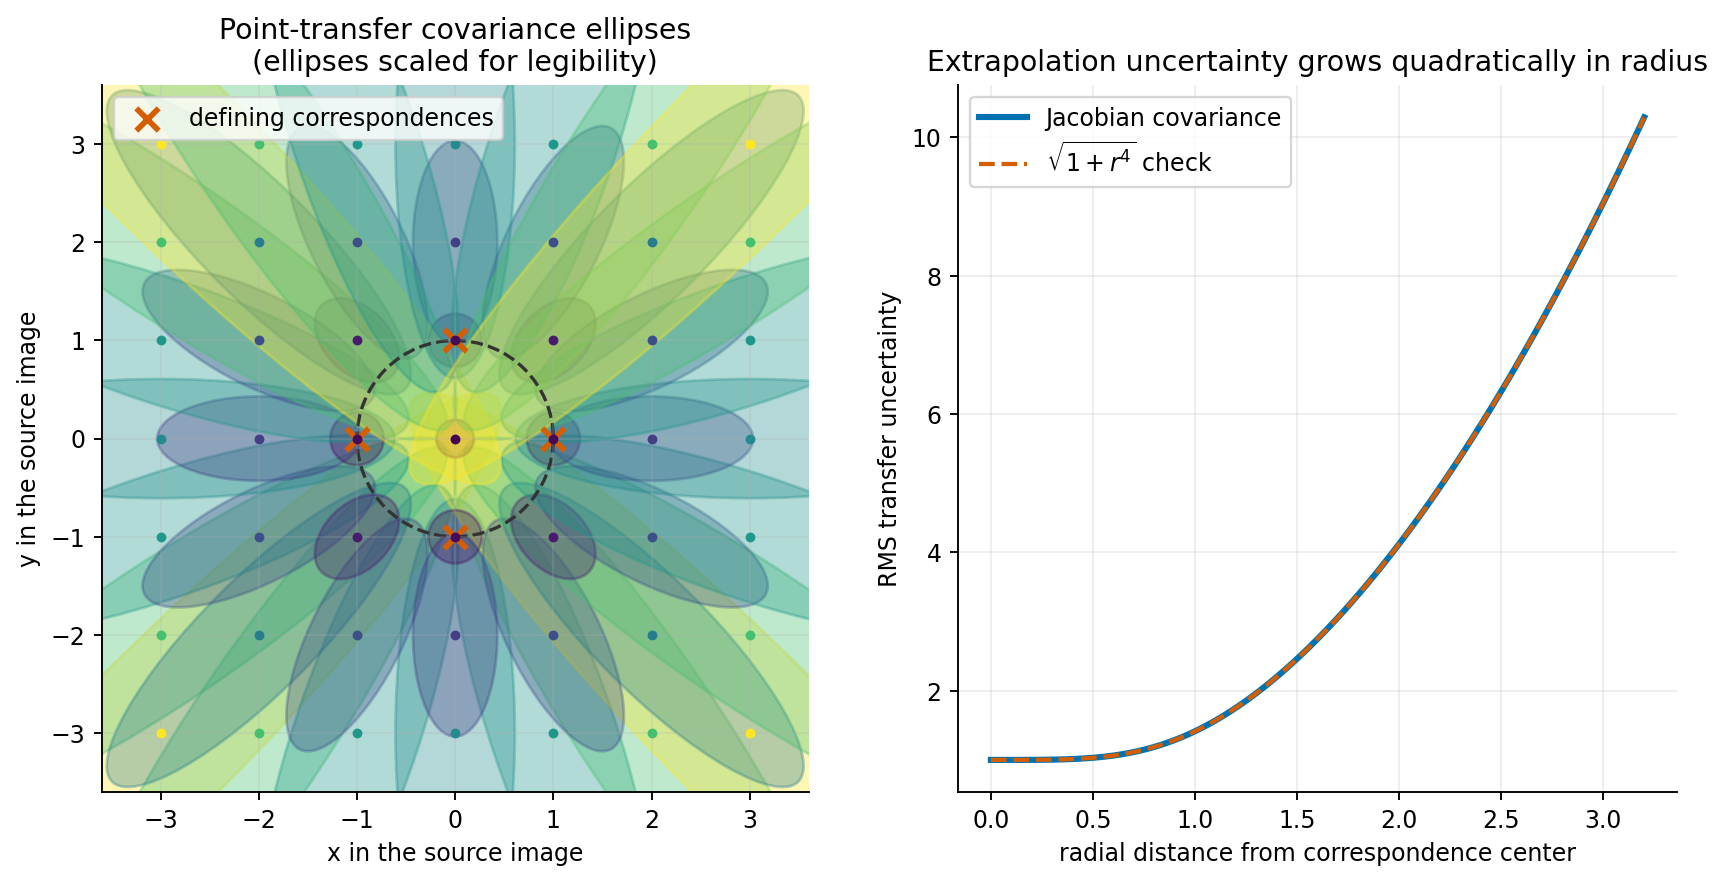

`artifacts/chapter-05/checks/point-transfer-covariance-checks.json`

{'information_rank': 8,
 'homography_covariance_min_eigenvalue': -1.3900091192408058e-16,
 'probe_rms_min': 1.0,
 'probe_rms_max': 18.02775637731995,
 'radial_formula_max_abs_error': 3.552713678800501e-15,
 'probe_trace_from_homography_covariance': 26.000000000000007,
 'probe_trace_after_adding_source_point_noise': 26.125000000000007}

In [4]:
unit_correspondences = np.array([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0]])
H_identity = np.eye(3)
sigma_measurement = 1.0
J_stack = np.vstack([homography_transfer_jacobian(H_identity, point) for point in unit_correspondences])
information = (J_stack.T @ J_stack) / sigma_measurement**2
Sigma_h = np.linalg.pinv(information, rcond=1e-12)

probe_grid = np.array([[x, y] for y in np.linspace(-3, 3, 7) for x in np.linspace(-3, 3, 7)], dtype=float)
probe_covariances = [homography_transfer_jacobian(H_identity, p) @ Sigma_h @ homography_transfer_jacobian(H_identity, p).T for p in probe_grid]
probe_rms = np.array([math.sqrt(float(np.trace(cov))) for cov in probe_covariances])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.4))
ax = axes[0]
colors = plt.cm.viridis((probe_rms - probe_rms.min()) / (probe_rms.max() - probe_rms.min()))
for point, cov, color in zip(probe_grid, probe_covariances, colors):
    add_covariance_ellipse(ax, point, cov, color=color, level=0.68, visual_scale=0.18, alpha=0.34)
    ax.scatter(point[0], point[1], s=10, color=color, zorder=3)
ax.scatter(unit_correspondences[:, 0], unit_correspondences[:, 1], marker="x", s=90, color="#D55E00", lw=2.4, label="defining correspondences")
circle = plt.Circle((0, 0), 1.0, fill=False, color="#333333", lw=1.4, ls="--")
ax.add_patch(circle)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.6, 3.6)
ax.set_ylim(-3.6, 3.6)
ax.set_title("Point-transfer covariance ellipses/n(ellipses scaled for legibility)")
ax.set_xlabel("x in the source image")
ax.set_ylabel("y in the source image")
ax.legend(loc="upper left", frameon=True)

r_values = np.linspace(0.0, 3.2, 120)
computed_rms = []
for r in r_values:
    cov = homography_transfer_jacobian(H_identity, np.array([r, 0.0])) @ Sigma_h @ homography_transfer_jacobian(H_identity, np.array([r, 0.0])).T
    computed_rms.append(math.sqrt(float(np.trace(cov))))
computed_rms = np.array(computed_rms)
radial_formula = np.sqrt(1.0 + r_values**4)
axes[1].plot(r_values, computed_rms, color="#0072B2", lw=2.6, label="Jacobian covariance")
axes[1].plot(r_values, radial_formula, color="#D55E00", lw=1.8, ls="--", label=r"$\sqrt{1+r^4}$ check")
axes[1].set_xlabel("radial distance from correspondence center")
axes[1].set_ylabel("RMS transfer uncertainty")
axes[1].set_title("Extrapolation uncertainty grows quadratically in radius")
axes[1].legend(frameon=True)

ellipse_path = save_matplotlib(fig, TOPIC, "figures", "point-transfer-covariance-ellipses.png", dpi=170)
plt.close(fig)
artifact_paths.append(ellipse_path)
display_artifact(ellipse_path, width=930)

source_point_sigma = 0.25
probe = np.array([2.0, 1.0])
Jh = homography_transfer_jacobian(H_identity, probe)
Jx = transfer_jacobian_wrt_point(H_identity, probe)
probe_cov_from_H = Jh @ Sigma_h @ Jh.T
probe_cov_with_source = probe_cov_from_H + Jx @ (source_point_sigma**2 * np.eye(2)) @ Jx.T

covariance_checks = {
    "information_rank": int(np.linalg.matrix_rank(information, tol=1e-9)),
    "homography_covariance_min_eigenvalue": float(np.linalg.eigvalsh((Sigma_h + Sigma_h.T) / 2.0).min()),
    "probe_rms_min": float(probe_rms.min()),
    "probe_rms_max": float(probe_rms.max()),
    "radial_formula_max_abs_error": float(np.max(np.abs(computed_rms - radial_formula))),
    "probe_trace_from_homography_covariance": float(np.trace(probe_cov_from_H)),
    "probe_trace_after_adding_source_point_noise": float(np.trace(probe_cov_with_source)),
}
cov_checks_path = save_json(covariance_checks, TOPIC, "checks", "point-transfer-covariance-checks.json")
check_paths.append(cov_checks_path)
display_artifact(cov_checks_path)

assert covariance_checks["information_rank"] == 8
assert covariance_checks["homography_covariance_min_eigenvalue"] > -1e-9
assert covariance_checks["radial_formula_max_abs_error"] < 1e-9
assert covariance_checks["probe_trace_after_adding_source_point_noise"] > covariance_checks["probe_trace_from_homography_covariance"]
covariance_checks


## Noise Sweep: Empirical Diagnostics Against The Bound

The bound is a target for an optimal geometric estimator under small Gaussian noise. A linear DLT homography estimator is not exactly the maximum-likelihood estimator, but after coordinate normalization it should track the bound in a clean synthetic experiment. That makes the sweep a useful diagnostic: if the empirical residuals are wildly above the curves, either the noise is too large for the local linear model, the point layout is poorly conditioned, or the implementation is failing.

This experiment keeps the source image points exact, adds Gaussian noise only to the second image, estimates the homography repeatedly, and records residual RMS, estimation RMS, and the Pythagorean gap. The static artifact is for durable reading; the Plotly HTML lets you inspect the same data interactively.


[homography-noise-sweep-reprojection-diagnostics.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-05/tables/homography-noise-sweep-reprojection-diagnostics.csv)

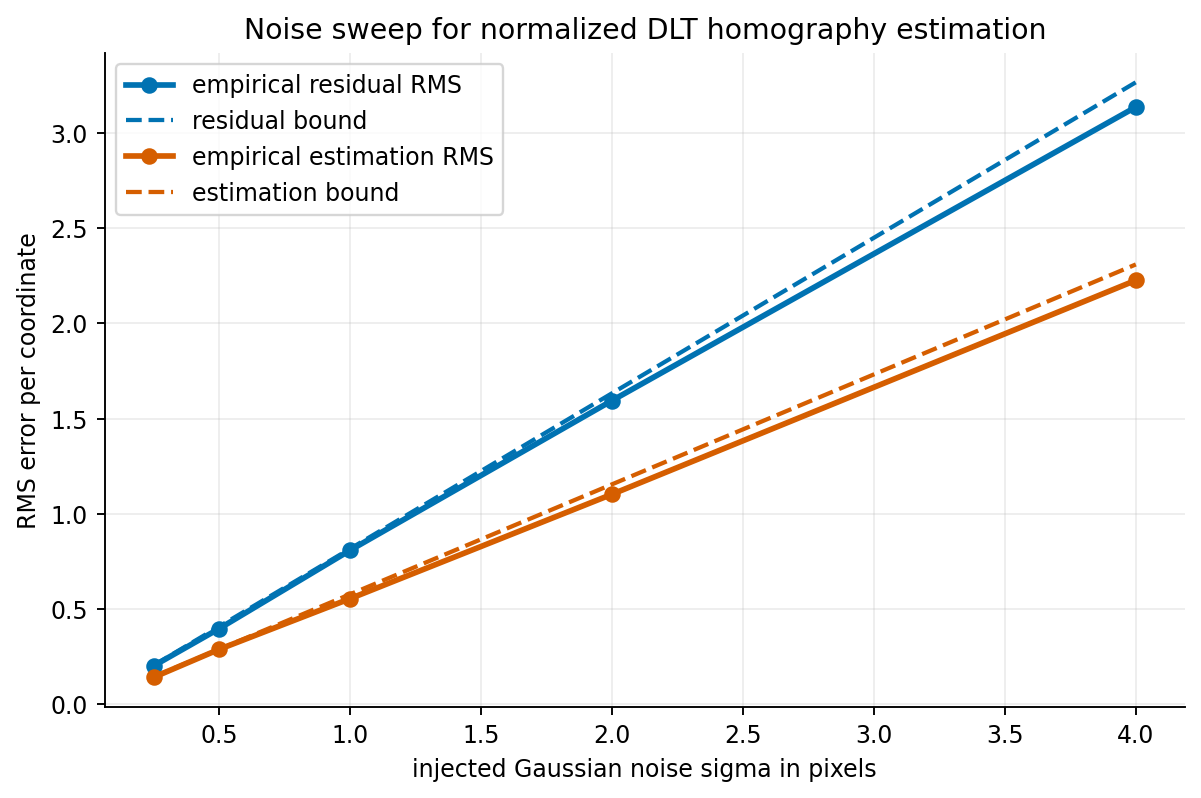

.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


`artifacts/chapter-05/checks/noise-sweep-diagnostics-checks.json`

{'trial_count': 1800,
 'trials_per_noise_level': 360,
 'source_correspondence_count': 12,
 'opencv_dlt_noiseless_reprojection_rms_difference': 8.904502066549193e-06,
 'residual_ratio_min': 0.9601946497340618,
 'residual_ratio_max': 0.9902973380775859,
 'estimation_ratio_min': 0.9548820392467713,
 'estimation_ratio_max': 0.9985793777960964,
 'mean_pythagorean_gap_max': 0.009922815781459463}

In [5]:
src_points = np.array([
    [100.0, 100.0], [400.0, 80.0], [780.0, 120.0], [1120.0, 160.0],
    [130.0, 500.0], [480.0, 520.0], [790.0, 475.0], [1180.0, 540.0],
    [90.0, 900.0], [420.0, 930.0], [760.0, 870.0], [1110.0, 920.0],
])
H_true = np.array([[1.0, 0.08, 120.0], [-0.04, 0.95, 75.0], [1.0e-4, -7.0e-5, 1.0]])
dst_true = apply_homography(H_true, src_points)

H_cv_noiseless = opencv_homography(src_points, dst_true)
H_dlt_noiseless, _ = dlt_homography(src_points, dst_true, normalized=True)
opencv_crosscheck_error = rms_per_coordinate(apply_homography(H_cv_noiseless, src_points), apply_homography(H_dlt_noiseless, src_points))

noise_levels = np.array([0.25, 0.5, 1.0, 2.0, 4.0])
trials_per_level = 360
sweep_rows: list[dict[str, float]] = []
for sigma_level in noise_levels:
    for trial in range(trials_per_level):
        noisy_dst = dst_true + rng.normal(scale=sigma_level, size=dst_true.shape)
        H_est, singular_values = dlt_homography(src_points, noisy_dst, normalized=True)
        fitted_dst = apply_homography(H_est, src_points)
        residual_rms = rms_per_coordinate(noisy_dst, fitted_dst)
        estimation_rms = rms_per_coordinate(dst_true, fitted_dst)
        noise_sq = float(np.sum((noisy_dst - dst_true) ** 2))
        residual_sq = float(np.sum((noisy_dst - fitted_dst) ** 2))
        estimation_sq = float(np.sum((fitted_dst - dst_true) ** 2))
        pythagorean_relative_gap = abs(noise_sq - residual_sq - estimation_sq) / max(noise_sq, 1e-12)
        sweep_rows.append({
            "sigma": float(sigma_level),
            "trial": float(trial),
            "residual_rms": residual_rms,
            "estimation_rms": estimation_rms,
            "pythagorean_relative_gap": pythagorean_relative_gap,
            "dlt_smallest_singular_ratio": float(singular_values[-1] / singular_values[-2]),
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_summary = sweep_df.groupby("sigma", as_index=False).agg(
    residual_mean=("residual_rms", "mean"),
    residual_median=("residual_rms", "median"),
    estimation_mean=("estimation_rms", "mean"),
    estimation_median=("estimation_rms", "median"),
    pythagorean_gap_mean=("pythagorean_relative_gap", "mean"),
)
n = len(src_points)
sweep_summary["residual_bound"] = sweep_summary["sigma"] * math.sqrt(1.0 - 4.0 / n)
sweep_summary["estimation_bound"] = sweep_summary["sigma"] * math.sqrt(4.0 / n)
sweep_summary["residual_mean_to_bound"] = sweep_summary["residual_mean"] / sweep_summary["residual_bound"]
sweep_summary["estimation_mean_to_bound"] = sweep_summary["estimation_mean"] / sweep_summary["estimation_bound"]

sweep_table_path = save_csv(sweep_summary.to_dict("records"), TOPIC, "tables", "homography-noise-sweep-reprojection-diagnostics.csv")
table_paths.append(sweep_table_path)
display_artifact(sweep_table_path)

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(sweep_summary["sigma"], sweep_summary["residual_mean"], marker="o", color="#0072B2", lw=2.4, label="empirical residual RMS")
ax.plot(sweep_summary["sigma"], sweep_summary["residual_bound"], color="#0072B2", lw=1.8, ls="--", label="residual bound")
ax.plot(sweep_summary["sigma"], sweep_summary["estimation_mean"], marker="o", color="#D55E00", lw=2.4, label="empirical estimation RMS")
ax.plot(sweep_summary["sigma"], sweep_summary["estimation_bound"], color="#D55E00", lw=1.8, ls="--", label="estimation bound")
ax.set_xlabel("injected Gaussian noise sigma in pixels")
ax.set_ylabel("RMS error per coordinate")
ax.set_title("Noise sweep for normalized DLT homography estimation")
ax.legend(frameon=True)

sweep_png_path = save_matplotlib(fig, TOPIC, "figures", "homography-noise-sweep-reprojection-diagnostics.png", dpi=170)
plt.close(fig)
artifact_paths.append(sweep_png_path)
display_artifact(sweep_png_path, width=850)

fig_html = go.Figure()
fig_html.add_trace(go.Scatter(x=sweep_summary["sigma"], y=sweep_summary["residual_mean"], mode="lines+markers", name="empirical residual RMS"))
fig_html.add_trace(go.Scatter(x=sweep_summary["sigma"], y=sweep_summary["residual_bound"], mode="lines", name="residual bound", line=dict(dash="dash")))
fig_html.add_trace(go.Scatter(x=sweep_summary["sigma"], y=sweep_summary["estimation_mean"], mode="lines+markers", name="empirical estimation RMS"))
fig_html.add_trace(go.Scatter(x=sweep_summary["sigma"], y=sweep_summary["estimation_bound"], mode="lines", name="estimation bound", line=dict(dash="dash")))
fig_html.update_layout(
    title="Chapter 05 noise sweep: residual and estimation diagnostics",
    xaxis_title="noise sigma in pixels",
    yaxis_title="RMS error per coordinate",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
sweep_html_path = save_plotly_html(fig_html, TOPIC, "interactive", "homography-noise-sweep-reprojection-diagnostics.html")
artifact_paths.append(sweep_html_path)
display_artifact(sweep_html_path, width=900, height=520)

noise_sweep_checks = {
    "trial_count": int(len(sweep_df)),
    "trials_per_noise_level": int(trials_per_level),
    "source_correspondence_count": int(n),
    "opencv_dlt_noiseless_reprojection_rms_difference": float(opencv_crosscheck_error),
    "residual_ratio_min": float(sweep_summary["residual_mean_to_bound"].min()),
    "residual_ratio_max": float(sweep_summary["residual_mean_to_bound"].max()),
    "estimation_ratio_min": float(sweep_summary["estimation_mean_to_bound"].min()),
    "estimation_ratio_max": float(sweep_summary["estimation_mean_to_bound"].max()),
    "mean_pythagorean_gap_max": float(sweep_summary["pythagorean_gap_mean"].max()),
}
noise_checks_path = save_json(noise_sweep_checks, TOPIC, "checks", "noise-sweep-diagnostics-checks.json")
check_paths.append(noise_checks_path)
display_artifact(noise_checks_path)

assert opencv_crosscheck_error < 1e-4
assert np.all(np.diff(sweep_summary["residual_mean"]) > 0.0)
assert np.all(np.diff(sweep_summary["estimation_mean"]) > 0.0)
assert 0.90 < noise_sweep_checks["residual_ratio_min"] < 1.10
assert 0.90 < noise_sweep_checks["residual_ratio_max"] < 1.10
assert 0.90 < noise_sweep_checks["estimation_ratio_min"] < 1.10
assert 0.90 < noise_sweep_checks["estimation_ratio_max"] < 1.10
assert noise_sweep_checks["mean_pythagorean_gap_max"] < 0.03
noise_sweep_checks


## Monte Carlo Spread: Reprojection Can Hide Degeneracy

The covariance of the transformation depends on the point configuration, not just on the number of points or the image noise. A nearly collinear set of correspondences can still produce a small training residual because the estimated homography fits the measured points along the line. The same estimate can be wildly unreliable when asked to transfer a point away from that line.

The next cell runs the same normalized DLT estimator under two layouts: a well-spread grid-like layout and a nearly collinear layout. For each noisy trial it transfers a probe point that lies outside the measured region, records the probe prediction, and summarizes bias, variance, and reprojection residual. The point cloud is the empirical covariance story that the previous Jacobian cell predicted locally.


[monte-carlo-configuration-spread-summary.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-05/tables/monte-carlo-configuration-spread-summary.csv)

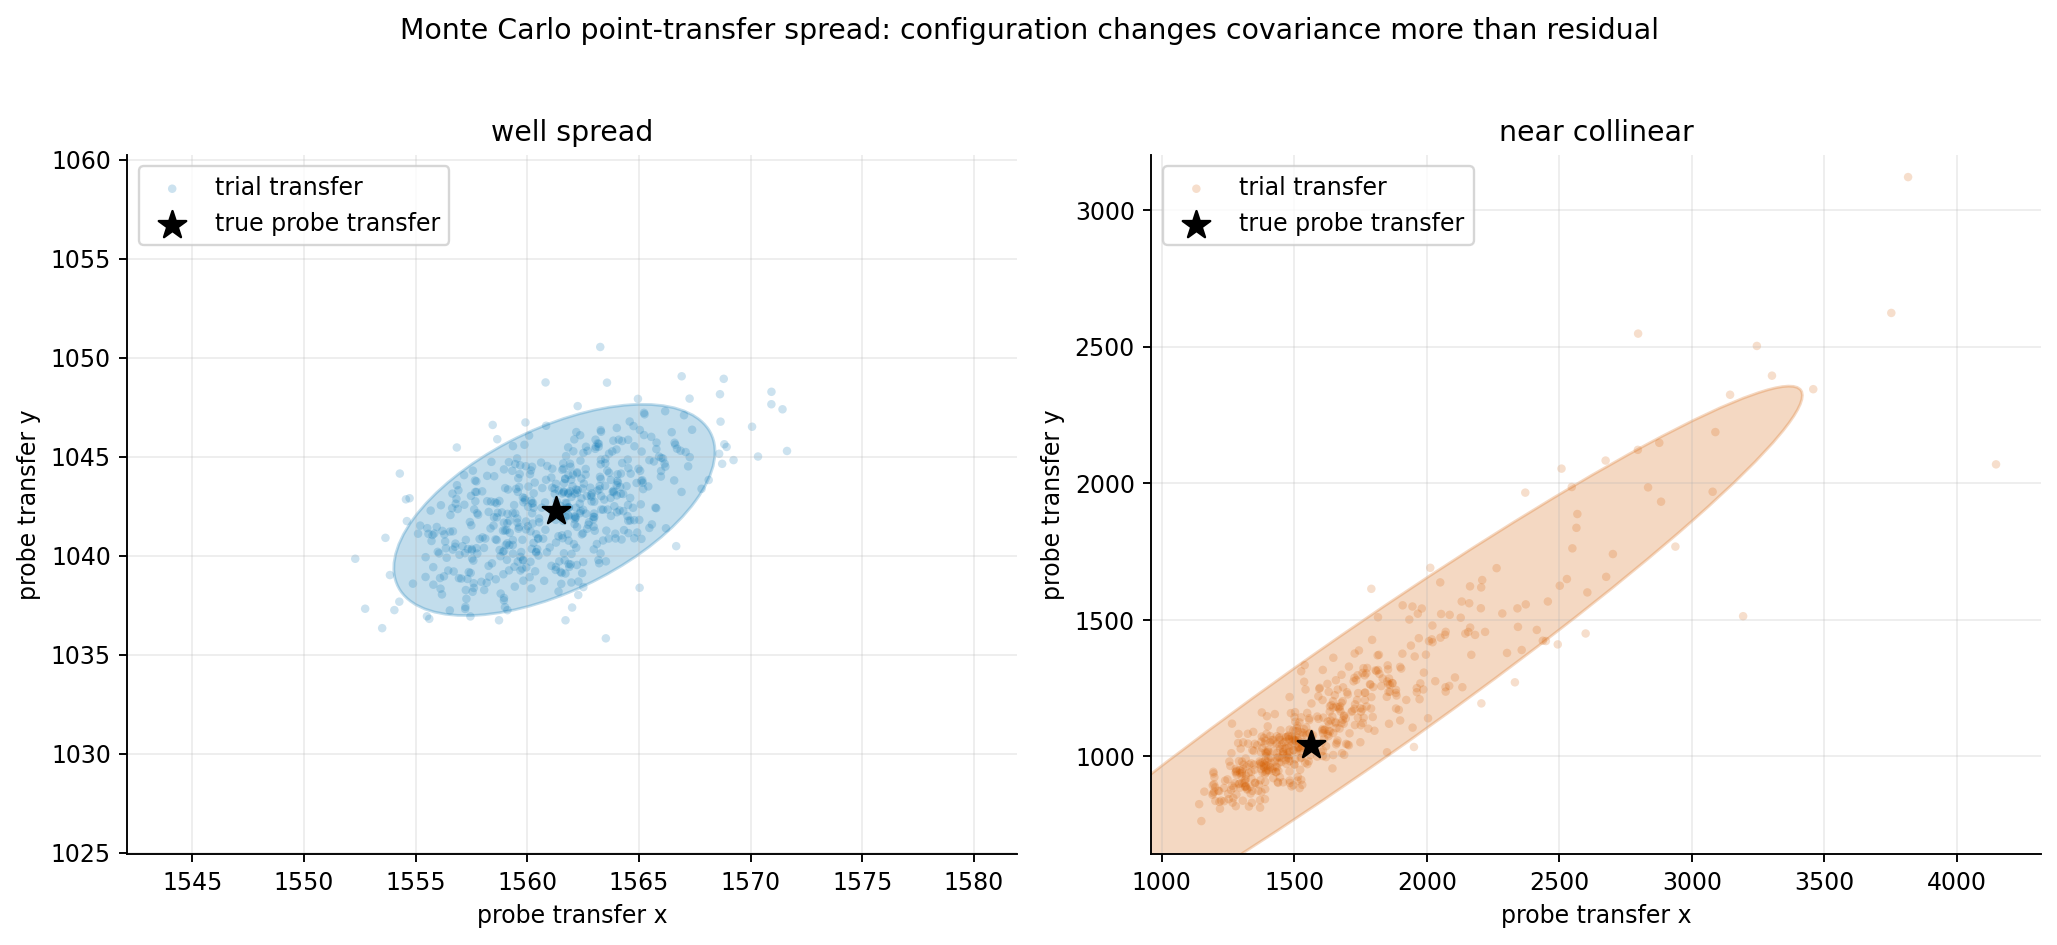

`artifacts/chapter-05/checks/monte-carlo-configuration-spread-checks.json`

{'monte_carlo_trials_per_layout': 520,
 'probe_true_x': 1561.2963832785344,
 'probe_true_y': 1042.2733677782996,
 'well_spread_probe_covariance_trace': 17.40945805811235,
 'near_collinear_probe_covariance_trace': 918032.8246696782,
 'covariance_trace_ratio_near_to_well': 52731.843898029845,
 'well_spread_median_training_residual': 1.5913822358240348,
 'near_collinear_median_training_residual': 1.6426391281118367,
 'max_covariance_min_eigenvalue_defect': 0.0}

In [6]:
line_x = np.linspace(100.0, 1120.0, len(src_points))
near_collinear_points = np.column_stack([
    line_x,
    520.0 + 0.03 * (line_x - 600.0) + 10.0 * np.sin(np.linspace(0.0, 2.0 * np.pi, len(src_points))),
])
layouts = {
    "well_spread": src_points,
    "near_collinear": near_collinear_points,
}
probe_point = np.array([[1450.0, 1150.0]])
true_probe = apply_homography(H_true, probe_point)[0]
mc_sigma = 2.0
mc_trials = 520
mc_rows: list[dict[str, float | str]] = []

for layout_name, layout_src in layouts.items():
    layout_dst_true = apply_homography(H_true, layout_src)
    for trial in range(mc_trials):
        noisy_dst = layout_dst_true + rng.normal(scale=mc_sigma, size=layout_dst_true.shape)
        H_est, singular_values = dlt_homography(layout_src, noisy_dst, normalized=True)
        fitted_dst = apply_homography(H_est, layout_src)
        predicted_probe = apply_homography(H_est, probe_point)[0]
        mc_rows.append({
            "layout": layout_name,
            "trial": trial,
            "probe_x": float(predicted_probe[0]),
            "probe_y": float(predicted_probe[1]),
            "probe_error": float(np.linalg.norm(predicted_probe - true_probe)),
            "training_residual_rms": rms_per_coordinate(noisy_dst, fitted_dst),
            "dlt_smallest_singular_ratio": float(singular_values[-1] / singular_values[-2]),
        })

mc_df = pd.DataFrame(mc_rows)
summary_rows = []
for layout_name, group in mc_df.groupby("layout"):
    pts = group[["probe_x", "probe_y"]].to_numpy()
    covariance = np.cov(pts.T)
    mean_probe = pts.mean(axis=0)
    summary_rows.append({
        "layout": layout_name,
        "mean_probe_x": float(mean_probe[0]),
        "mean_probe_y": float(mean_probe[1]),
        "probe_bias_pixels": float(np.linalg.norm(mean_probe - true_probe)),
        "probe_covariance_trace": float(np.trace(covariance)),
        "probe_rmse_pixels": float(np.sqrt(np.mean(np.sum((pts - true_probe) ** 2, axis=1)))),
        "median_training_residual_rms": float(group["training_residual_rms"].median()),
        "median_dlt_smallest_singular_ratio": float(group["dlt_smallest_singular_ratio"].median()),
        "covariance_min_eigenvalue": float(np.linalg.eigvalsh((covariance + covariance.T) / 2.0).min()),
    })
mc_summary = pd.DataFrame(summary_rows).sort_values("layout")
mc_table_path = save_csv(mc_summary.to_dict("records"), TOPIC, "tables", "monte-carlo-configuration-spread-summary.csv")
table_paths.append(mc_table_path)
display_artifact(mc_table_path)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.4))
layout_colors = {"well_spread": "#0072B2", "near_collinear": "#D55E00"}
for ax, layout_name in zip(axes, ["well_spread", "near_collinear"]):
    group = mc_df[mc_df["layout"] == layout_name]
    pts = group[["probe_x", "probe_y"]].to_numpy()
    keep_x = np.quantile(pts[:, 0], [0.01, 0.99])
    keep_y = np.quantile(pts[:, 1], [0.01, 0.99])
    ax.scatter(pts[:, 0], pts[:, 1], s=13, alpha=0.20, color=layout_colors[layout_name], edgecolors="none", label="trial transfer")
    ax.scatter(*true_probe, marker="*", s=150, color="#000000", zorder=5, label="true probe transfer")
    add_covariance_ellipse(ax, pts.mean(axis=0), np.cov(pts.T), color=layout_colors[layout_name], level=0.90, alpha=0.24)
    ax.set_title(layout_name.replace("_", " "))
    ax.set_xlabel("probe transfer x")
    ax.set_ylabel("probe transfer y")
    pad_x = max(12.0, 0.08 * (keep_x[1] - keep_x[0]))
    pad_y = max(12.0, 0.08 * (keep_y[1] - keep_y[0]))
    ax.set_xlim(keep_x[0] - pad_x, keep_x[1] + pad_x)
    ax.set_ylim(keep_y[0] - pad_y, keep_y[1] + pad_y)
    ax.legend(frameon=True, loc="upper left")
fig.suptitle("Monte Carlo point-transfer spread: configuration changes covariance more than residual", y=1.02)
fig.tight_layout()

mc_spread_path = save_matplotlib(fig, TOPIC, "figures", "monte-carlo-configuration-spread.png", dpi=170)
plt.close(fig)
artifact_paths.append(mc_spread_path)
display_artifact(mc_spread_path, width=930)

well = mc_summary[mc_summary["layout"] == "well_spread"].iloc[0]
near = mc_summary[mc_summary["layout"] == "near_collinear"].iloc[0]
mc_checks = {
    "monte_carlo_trials_per_layout": int(mc_trials),
    "probe_true_x": float(true_probe[0]),
    "probe_true_y": float(true_probe[1]),
    "well_spread_probe_covariance_trace": float(well["probe_covariance_trace"]),
    "near_collinear_probe_covariance_trace": float(near["probe_covariance_trace"]),
    "covariance_trace_ratio_near_to_well": float(near["probe_covariance_trace"] / well["probe_covariance_trace"]),
    "well_spread_median_training_residual": float(well["median_training_residual_rms"]),
    "near_collinear_median_training_residual": float(near["median_training_residual_rms"]),
    "max_covariance_min_eigenvalue_defect": float(max(0.0, -mc_summary["covariance_min_eigenvalue"].min())),
}
mc_checks_path = save_json(mc_checks, TOPIC, "checks", "monte-carlo-configuration-spread-checks.json")
check_paths.append(mc_checks_path)
display_artifact(mc_checks_path)

assert mc_checks["max_covariance_min_eigenvalue_defect"] < 1e-6
assert mc_checks["covariance_trace_ratio_near_to_well"] > 1000.0
assert abs(mc_checks["near_collinear_median_training_residual"] - mc_checks["well_spread_median_training_residual"]) < 0.35
mc_checks


## Applied Lab: Design An Evaluation Run

Use the cells above as a template for evaluating another geometric estimator.

1. Generate or collect correspondences with known ground truth when possible.
2. State which coordinates are noisy and what covariance model is assumed.
3. Record both residual RMS and estimation RMS. A low residual alone is not enough.
4. Propagate covariance to the quantity you will actually use, such as a transferred point, epipolar line, or triangulated point.
5. Run Monte Carlo trials at several noise levels and at least two point configurations.
6. Report bias, variance, reprojection residual, singular-value diagnostics, and any convergence identity that applies.

For this chapter, the critical applied lesson is that evaluation is geometric. The same matrix estimate can look strong under one diagnostic and weak under another because residual, estimator covariance, point layout, and extrapolation are measuring different things.


## Final Sanity Checks

The final cell checks the notebook's core mathematical claims and artifact contract: all generated files exist, generic audit-trigger artifact names were avoided, covariance matrices are positive semidefinite to numerical tolerance, the tangent-plane identity closes, empirical noise curves track the bound, and the nearly collinear Monte Carlo layout has much larger transfer covariance despite similar training residual.


In [7]:
all_generated_paths = artifact_paths + table_paths + check_paths
assert_artifacts(artifact_paths, min_bytes=2500)
assert_artifacts(table_paths, min_bytes=80)
assert_artifacts(check_paths, min_bytes=120)

blocked_artifact_stems = [
    ("concept", "map", "png"),
    ("geometry", "scene", "png"),
    ("diagnostic", "dashboard", "png"),
    ("constraint", "dashboard", "png"),
    ("numeric", "summary", "json"),
]
generic_artifact_names = {f"{a}-{b}.{ext}" for a, b, ext in blocked_artifact_stems}
assert not any(path.name in generic_artifact_names for path in all_generated_paths)

final_sanity = {
    "source_span": "printed pages 132-150; PDF pages 150-168",
    "artifact_count": len(artifact_paths),
    "table_count": len(table_paths),
    "check_file_count": len(check_paths),
    "generated_paths": [relative_to_book(path, BOOK_ROOT) for path in all_generated_paths],
    "pythagorean_gap": bound_checks["pythagorean_gap"],
    "homography_information_rank": covariance_checks["information_rank"],
    "radial_covariance_formula_error": covariance_checks["radial_formula_max_abs_error"],
    "noise_sweep_residual_ratio_range": [noise_sweep_checks["residual_ratio_min"], noise_sweep_checks["residual_ratio_max"]],
    "noise_sweep_estimation_ratio_range": [noise_sweep_checks["estimation_ratio_min"], noise_sweep_checks["estimation_ratio_max"]],
    "monte_carlo_covariance_trace_ratio_near_to_well": mc_checks["covariance_trace_ratio_near_to_well"],
    "opencv_dlt_noiseless_reprojection_rms_difference": noise_sweep_checks["opencv_dlt_noiseless_reprojection_rms_difference"],
}

assert final_sanity["artifact_count"] >= 6
assert final_sanity["table_count"] >= 2
assert final_sanity["check_file_count"] >= 4
assert final_sanity["pythagorean_gap"] < 1e-12
assert final_sanity["homography_information_rank"] == 8
assert final_sanity["radial_covariance_formula_error"] < 1e-9
assert 0.90 < final_sanity["noise_sweep_residual_ratio_range"][0] < 1.10
assert 0.90 < final_sanity["noise_sweep_residual_ratio_range"][1] < 1.10
assert 0.90 < final_sanity["noise_sweep_estimation_ratio_range"][0] < 1.10
assert 0.90 < final_sanity["noise_sweep_estimation_ratio_range"][1] < 1.10
assert final_sanity["monte_carlo_covariance_trace_ratio_near_to_well"] > 1000.0
assert final_sanity["opencv_dlt_noiseless_reprojection_rms_difference"] < 1e-4
final_sanity


{'source_span': 'printed pages 132-150; PDF pages 150-168',
 'artifact_count': 6,
 'table_count': 2,
 'check_file_count': 4,
 'generated_paths': ['artifacts/chapter-05/figures/homography-error-bound-curves.png',
  'artifacts/chapter-05/figures/tangent-plane-convergence-identity.png',
  'artifacts/chapter-05/figures/point-transfer-covariance-ellipses.png',
  'artifacts/chapter-05/figures/homography-noise-sweep-reprojection-diagnostics.png',
  'artifacts/chapter-05/interactive/homography-noise-sweep-reprojection-diagnostics.html',
  'artifacts/chapter-05/figures/monte-carlo-configuration-spread.png',
  'artifacts/chapter-05/tables/homography-noise-sweep-reprojection-diagnostics.csv',
  'artifacts/chapter-05/tables/monte-carlo-configuration-spread-summary.csv',
  'artifacts/chapter-05/checks/performance-bound-and-tangent-plane-checks.json',
  'artifacts/chapter-05/checks/point-transfer-covariance-checks.json',
  'artifacts/chapter-05/checks/noise-sweep-diagnostics-checks.json',
  'artifac

## Takeaways

- Residual error and estimation error are different projections of the measurement noise.
- The tangent-plane approximation gives concrete bounds and a convergence identity, but the identity is only as reliable as the local linear model and the optimizer.
- Homography covariance is a Jacobian and pseudo-inverse problem because the matrix entries are homogeneous parameters.
- Error ellipses make covariance inspectable: they show anisotropy, extrapolation risk, and the effect of adding uncertainty in the source point.
- Monte Carlo trials are not a replacement for theory; they are the way to check whether the theory survives the estimator, noise scale, and point configuration actually being used.
